In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import mlflow
import mlflow.pytorch

from product_tagger.config import MLFLOW_TRACKING_URI

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

2025-12-05 21:23:02.076 | INFO     | product_tagger.config:<module>:12 - PROJ_ROOT path is: C:\importante\Master\VC3\TP-VPC3
c:\importante\Master\VC3\TP-VPC3\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025-12-05 21:23:02.090 | INFO     | product_tagger.config:<module>:64 - [MLflow] tracking_uri = file:///C:/importante/Master/VC3/TP-VPC3/mlruns
2025-12-05 21:23:02.103 | INFO     | product_tagger.config:<module>:67 - [MLflow] experiment 'vit_aug_loss' -> id=899493669112892091, artifact_location=file:///C:/importante/Master/VC3/TP-VPC3/mlruns/899493669112892091


Device: cuda


In [2]:
def get_model_from_mlflow(run_id: str, artifact_path: str = "model"):
    
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    model_uri = f"runs:/{run_id}/{artifact_path}"
    print("Loading model from:", model_uri)

    model = mlflow.pytorch.load_model(model_uri, map_location=device)
    model.to(device)
    model.eval()
    return model

In [3]:
def load_image_as_tensor(path, size=(224, 224)):
    
    img = Image.open(path).convert("RGB")
    pil_img = img.resize(size)

    arr = np.array(pil_img).astype("float32") / 255.0  # [H, W, C] 0–1
    arr = np.transpose(arr, (2, 0, 1))                 # [C, H, W]
    tensor = torch.from_numpy(arr).unsqueeze(0)        # [1, C, H, W]
    return tensor, pil_img


In [4]:
def compute_cls_attention_map(attn_maps, layer_idx=-1, head_fusion="mean"):

    attn = attn_maps[layer_idx] 
    attn = attn[0]               

    if head_fusion == "mean":
        attn = attn.mean(dim=0)      
    elif head_fusion == "max":
        attn, _ = attn.max(dim=0)
    else:
        raise ValueError("head_fusion must be 'mean' or 'max'")

    cls_attn = attn[0]      
    cls_attn = cls_attn[1:]  

    return cls_attn 


In [5]:
def cls_attention_to_map(cls_attn, img_size=(224, 224)):
    """
    Convierte el vector de atención (CLS→patches) en un mapa 2D del tamaño de la imagen.
    """
    num_patches = cls_attn.shape[0]
    grid = int(num_patches ** 0.5)  

    attn_map = cls_attn.reshape(1, 1, grid, grid)  

    attn_map = attn_map - attn_map.min()
    if attn_map.max() > 0:
        attn_map = attn_map / attn_map.max()

    attn_map = F.interpolate(attn_map, size=img_size, mode="bilinear", align_corners=False)
    attn_map = attn_map.squeeze().numpy()  # [H, W]

    return attn_map


In [6]:
def show_attention_overlay(pil_img, attn_map, alpha=0.5, cmap="jet", title="Attention map"):
    
    plt.figure(figsize=(6, 6))
    plt.imshow(pil_img)
    plt.imshow(attn_map, cmap=cmap, alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.show()


In [7]:
from pathlib import Path
from product_tagger.config import MODELS_DIR, PROCESSED_DATA_DIR
from product_tagger.config import PROCESSED_DATA_DIR

IMG_DIR  = PROCESSED_DATA_DIR / "images" / "test"

VALID_EXT = {".jpg", ".jpeg", ".png"}

all_images = [p for p in IMG_DIR.iterdir() if p.suffix.lower() in VALID_EXT]

def numeric_key(path: Path):
    try:
        return int(path.stem)  
    except ValueError:
        return float("inf")

all_images_sorted = sorted(all_images, key=numeric_key)

image_paths = all_images_sorted[:10]

print("Encontradas:", len(all_images_sorted), "imágenes")
print("Using this 10 images:")
for p in image_paths:
    print(" -", p.name)


Encontradas: 6663 imágenes
Using this 10 images:
 - 1163.jpg
 - 1530.jpg
 - 1535.jpg
 - 1543.jpg
 - 1546.jpg
 - 1579.jpg
 - 1583.jpg
 - 1584.jpg
 - 1587.jpg
 - 1594.jpg


In [8]:
RUN_ID = "ad484a8bc4194f869d930c7f1706a398" #Write the run id you want
ARTIFACT_PATH = "model"
IMG_PATH = IMG_DIR

model = get_model_from_mlflow(RUN_ID, ARTIFACT_PATH)

last_block = model.encoder.layers[-1]
print("Usando bloque:", last_block)

captured = {}

def enc_pre_hook(module, inputs):
    """
    Hook PRE-forward: guarda la entrada a last_block (x_block).
    inputs es una tupla; el primer elemento es x de ese bloque: [B, T, D]
    """
    x_block = inputs[0]
    captured["x_block"] = x_block.detach().to(device)

hook = last_block.register_forward_pre_hook(enc_pre_hook)

results = []  

for img_path in image_paths:
    print(f"\nProcesando: {img_path.name}")

    captured.clear()

    x, pil_img = load_image_as_tensor(str(img_path))
    x = x.to(device)

    with torch.no_grad():
        _ = model(x)

    if "x_block" not in captured:
        raise RuntimeError("No se capturó x_block para esta imagen")

    x_block = captured["x_block"]  # [B, T, D]

    y = last_block.ln_1(x_block)

    with torch.no_grad():
        attn_out, attn_weights = last_block.self_attention(
            y, y, y,
            need_weights=True,
            average_attn_weights=False,
        )

    attn_maps = [attn_weights.cpu()]
    cls_attn = compute_cls_attention_map(attn_maps, layer_idx=-1, head_fusion="mean")
    attn_map = cls_attention_to_map(cls_attn, img_size=pil_img.size[::-1])

    results.append((pil_img, attn_map))

hook.remove()

print("¿Se capturó x_block?", "x_block" in captured)
if "x_block" in captured:
    print("x_block shape:", captured["x_block"].shape)
else:
    raise RuntimeError("No se capturó la entrada al último bloque (x_block).")


Loading model from: runs:/ad484a8bc4194f869d930c7f1706a398/model


c:\importante\Master\VC3\TP-VPC3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Usando bloque: EncoderBlock(
  (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (self_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
  )
  (dropout): Dropout(p=0.0, inplace=False)
  (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
  (mlp): MLPBlock(
    (0): Linear(in_features=768, out_features=3072, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=3072, out_features=768, bias=True)
    (4): Dropout(p=0.0, inplace=False)
  )
)

Procesando: 1163.jpg

Procesando: 1530.jpg

Procesando: 1535.jpg

Procesando: 1543.jpg

Procesando: 1546.jpg

Procesando: 1579.jpg

Procesando: 1583.jpg

Procesando: 1584.jpg

Procesando: 1587.jpg

Procesando: 1594.jpg
¿Se capturó x_block? True
x_block shape: torch.Size([1, 197, 768])



Imagen 1/10


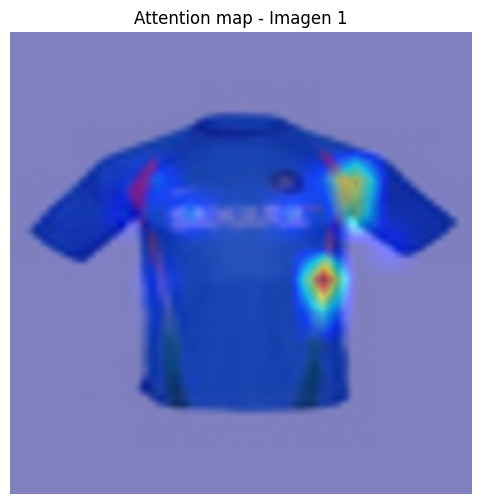


Imagen 2/10


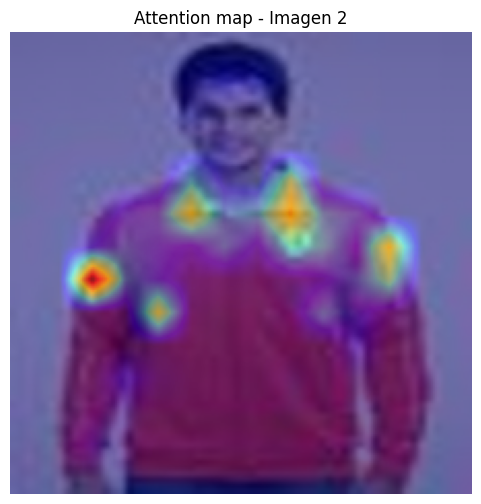


Imagen 3/10


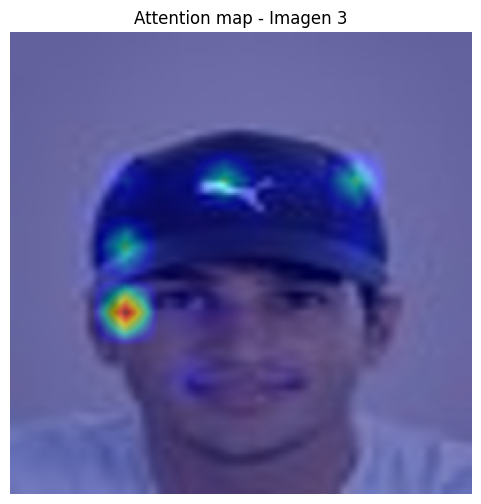


Imagen 4/10


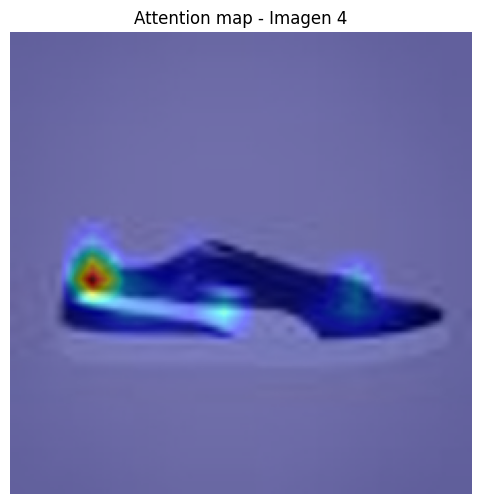


Imagen 5/10


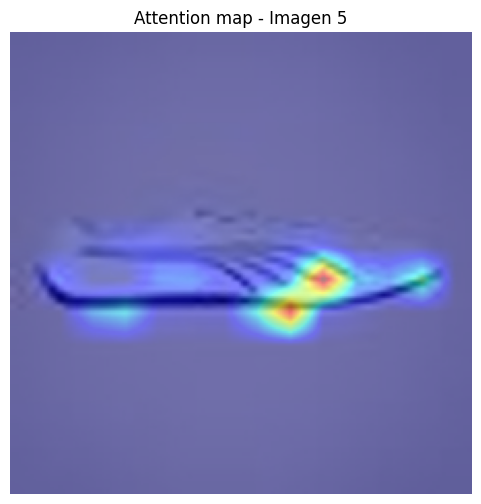


Imagen 6/10


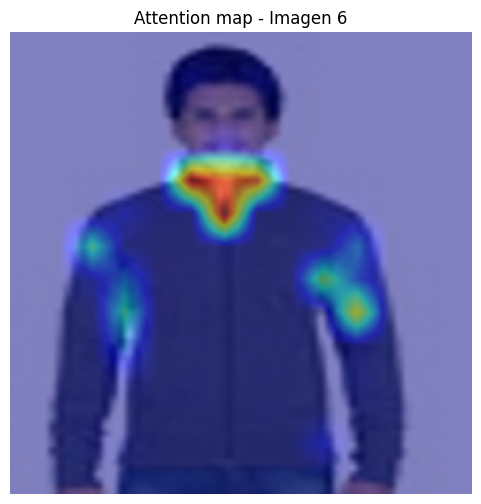


Imagen 7/10


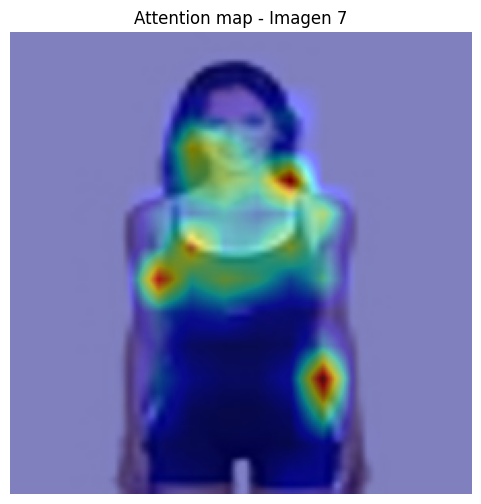


Imagen 8/10


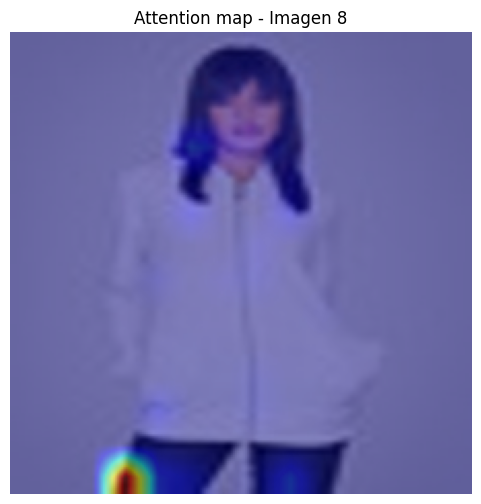


Imagen 9/10


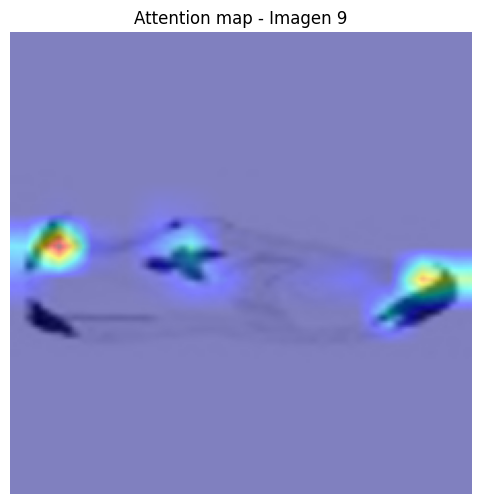


Imagen 10/10


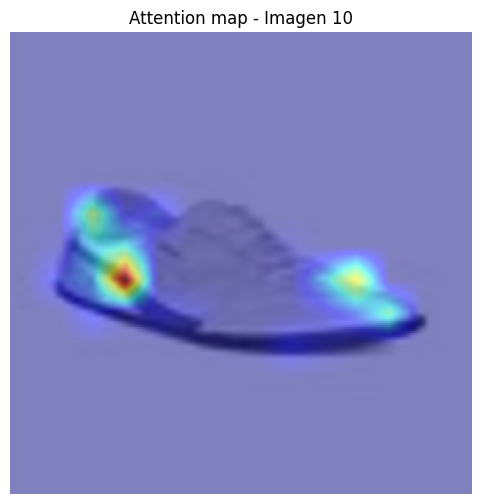

In [9]:
for idx, (pil_img, attn_map) in enumerate(results):
    print(f"\nImagen {idx+1}/{len(results)}")
    show_attention_overlay(pil_img, attn_map, alpha=0.5, cmap="jet",
                           title=f"Attention map - Imagen {idx+1}")
